In [3]:
from datasets import load_dataset
from transformers import GPT2TokenizerFast

import torch

tok = GPT2TokenizerFast.from_pretrained("gpt2")
tok.add_special_tokens({"mask_token": "[MASK]", "pad_token": "[PAD]"})
MASK_ID = tok.mask_token_id
PAD_ID  = tok.pad_token_id
VOCAB   = len(tok)
SEQ_LEN = 128

ds = load_dataset("roneneldan/TinyStories", split="train[:200000]")

def encode(batch):
    out = tok(batch["text"], truncation=True, max_length=SEQ_LEN,
              padding="max_length")
    return {"input_ids": out["input_ids"], "attention_mask": out["attention_mask"]}

ds = ds.map(encode, batched=True, remove_columns=["text"])
ds.set_format("torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

In [ ]:


def mask_prob(t):                 # t in [0,1]; cosine usually samples better
    return 1 - torch.cos(torch.pi * t / 2)

def corrupt(x, t):
    p = mask_prob(t).unsqueeze(1)
    mask = torch.rand_like(x.float()) < p
    x_t = torch.where(mask, MASK_ID, x)
    return x_t, mask

## Visualizing the corruption process

As `t` goes from 0 → 1, the cosine schedule masks an increasing fraction of tokens.
Below: (1) the decoded text at a few timesteps, (2) a token-level heatmap of which
positions are masked, and (3) the empirical vs. theoretical mask fraction.

Original:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so

t=0.1  (0% masked):  One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so
t=0.3  (5% masked):  One day,[MASK] little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her[MASK], so
t=0.5  (35% masked):  [MASK] day,[MASK] little girl named[MASK] found[MASK] needle in her room[MASK][MASK] knew it[MASK][MASK] to play[MASK] it[MASK] it[MASK][MASK]. Lily wanted to[MASK] the needle[MASK] her mom, so
t=0.7  (68% masked):  One[MASK][MASK] a[MASK][MASK][MASK][MASK][MASK][MASK][MASK] in[MASK][MASK].[MASK][MASK][MASK] was difficult to play with[MASK][MASK][MASK] was[MASK][MASK][MASK][MASK][MASK][MASK]

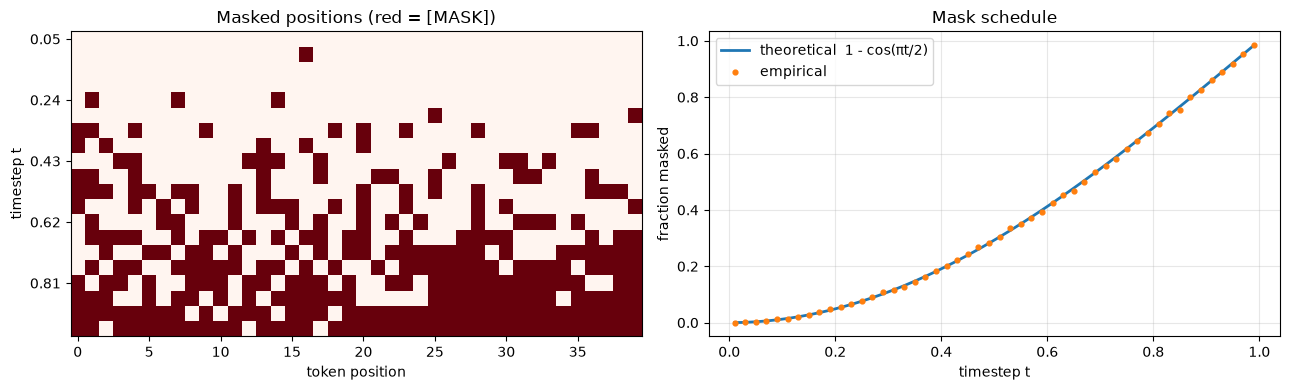

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- grab one real example and trim padding for readability ---
example = ds[0]
ids  = example["input_ids"]
attn = example["attention_mask"].bool()
real = ids[attn]                      # drop padding
n_show = min(40, real.numel())        # only show the first ~40 tokens
real = real[:n_show].unsqueeze(0)     # shape (1, n_show)

torch.manual_seed(0)
timesteps = torch.tensor([0.1, 0.3, 0.5, 0.7, 0.9])

# --- 1) decoded text at a few timesteps -------------------------------------
print("Original:\n" + tok.decode(real[0]) + "\n")
for t in timesteps:
    x_t, mask = corrupt(real, t.view(1))
    # show [MASK] inline where corrupted
    toks = [tok.mask_token if m else tok.decode([i])
            for i, m in zip(x_t[0].tolist(), mask[0].tolist())]
    print(f"t={t:.1f}  ({mask.float().mean():.0%} masked):  " + "".join(toks))

# --- 2) heatmap of masked positions across timesteps ------------------------
grid_t = torch.linspace(0.05, 0.95, 20)
heat = np.stack([corrupt(real, t.view(1))[1][0].numpy() for t in grid_t])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.imshow(heat, aspect="auto", cmap="Reds", interpolation="nearest")
ax1.set_xlabel("token position")
ax1.set_ylabel("timestep t")
ax1.set_yticks(range(0, 20, 4))
ax1.set_yticklabels([f"{grid_t[i]:.2f}" for i in range(0, 20, 4)])
ax1.set_title("Masked positions (red = [MASK])")

# --- 3) empirical vs theoretical mask fraction ------------------------------
ts = torch.linspace(0.01, 0.99, 50)
theo = mask_prob(ts).numpy()
emp = []
for t in ts:
    # average masked fraction over many samples of the full (real) sequence
    xb = real.repeat(256, 1)
    _, m = corrupt(xb, t.repeat(256))
    emp.append(m.float().mean().item())

ax2.plot(ts.numpy(), theo, label="theoretical  1 - cos(πt/2)", lw=2)
ax2.scatter(ts.numpy(), emp, s=12, color="C1", label="empirical", zorder=3)
ax2.set_xlabel("timestep t")
ax2.set_ylabel("fraction masked")
ax2.set_title("Mask schedule")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Animated GIF of the corruption process

Each token is a colored cell (color = a stable hash of its token id). As `t` ramps
from 0 → 1 the cosine schedule masks more tokens; masked cells turn dark and show
`[M]`. The masking is **monotonic** (a token, once masked, stays masked) so the
animation reads as progressively dissolving text. Saved to `corruption.gif`.

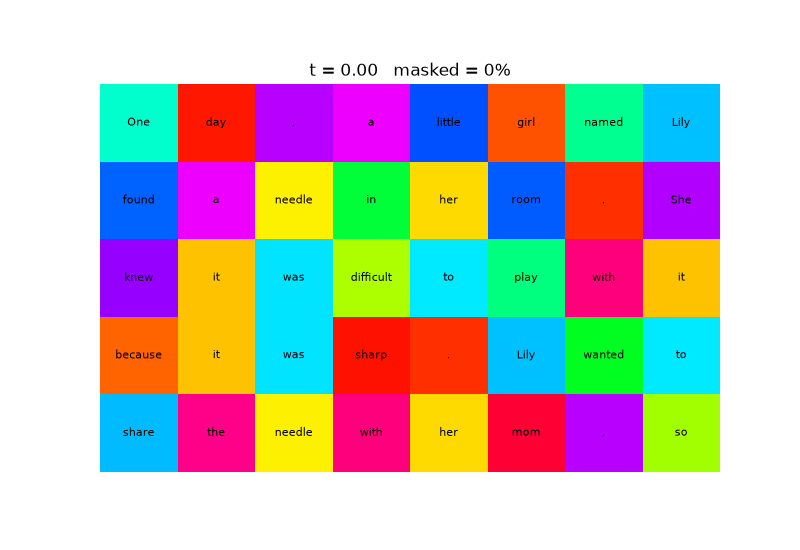

In [11]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import Image

# --- sequence to animate (padding already trimmed in `real`) ----------------
seq = real[0]
n   = seq.numel()
ncols = 8
nrows = int(np.ceil(n / ncols))
pad_cells = nrows * ncols - n
grid_ids = torch.cat([seq, torch.full((pad_cells,), -1)])   # -1 = empty cell

# --- stable color per token id (golden-ratio hashing spreads hues) ----------
cmap = plt.get_cmap("hsv")
def id_color(i):
    return cmap((int(i) * 0.61803398875) % 1.0)

base_colors = np.array(
    [id_color(t) if t >= 0 else (1, 1, 1, 1) for t in grid_ids]
).reshape(nrows, ncols, 4)
decoded = [tok.decode([int(t)]).strip() if t >= 0 else "" for t in grid_ids]

# --- monotonic mask order: token i masks once mask_prob(t) > u_i ------------
torch.manual_seed(0)
u = torch.rand(n)
MASK_COLOR = np.array([0.12, 0.12, 0.12, 1.0])
frames_t = torch.linspace(0.0, 1.0, 40)

fig, ax = plt.subplots(figsize=(ncols, nrows + 0.5))
ax.axis("off")
im = ax.imshow(base_colors)
texts = []
for r in range(nrows):
    for c in range(ncols):
        idx = r * ncols + c
        texts.append(ax.text(c, r, decoded[idx], ha="center", va="center",
                             fontsize=8, color="black"))
title = ax.set_title("")

def update(frame):
    t = frames_t[frame]
    masked = (mask_prob(t) > u)                  # (n,) monotonic in t
    img = base_colors.reshape(-1, 4).copy()
    for i in range(n):
        if masked[i]:
            img[i] = MASK_COLOR
        texts[i].set_text("[M]" if masked[i] else decoded[i])
        texts[i].set_color("white" if masked[i] else "black")
    im.set_array(img.reshape(nrows, ncols, 4))
    title.set_text(f"t = {t:.2f}   masked = {masked.float().mean():.0%}")
    return [im, *texts, title]

anim = animation.FuncAnimation(fig, update, frames=len(frames_t),
                               interval=120, blit=False)
gif_path = "corruption.gif"
anim.save(gif_path, writer=animation.PillowWriter(fps=8))
plt.close(fig)

Image(filename=gif_path)